# 11 - OLS por familias de variables (`v2`)

Esta notebook revisa el primer eje diagnóstico del programa OLS:

> ¿Qué familias de variables agregan señal predictiva lineal, y qué fallas permanecen aun después de agregarlas?

La unidad de análisis no es el “mejor modelo”, sino la secuencia de información que entra al diseño lineal.

La secuencia principal queda definida como:

1. `ols_demo` — demografía.
2. `ols_demo_educ` — demografía + educación.
3. `ols_demo_educ_labor` — demografía + educación + variables laborales.
4. `ols_core_no_pyramid` — benchmark limpio: agrega hogar/vivienda, sin pirámide etaria del hogar.

`ols_core`, que incluye variables tipo *household pyramid*, se reporta aparte como ablation. La razón es metodológica: esa extensión mejora algo el ajuste, pero agrega complejidad interpretativa y no cambia la historia principal.

La notebook evita gráficos de pocos números agregados. Las métricas agregadas van como tablas. Las figuras se reservan para fenómenos visuales: compresión de predicciones, estructura de residuales y distribución de errores.


## 00. Setup y descubrimiento de runs

La notebook consume artifacts ya producidos por el backend. No entrena modelos.

Layout esperado:

```text
reports/runs/<run_id>/
  metrics/model_comparison.csv
  predictions/validation_predictions.parquet
  predictions/test_predictions.parquet
  diagnostics/distribution_compression_summary.csv
  diagnostics/error_by_income_decile.csv
  feature_columns.json
  dataset_card.json
  config_used.yaml
```

Los outputs de esta versión se escriben en:

```text
reports/notebook_outputs/ols_feature_blocks_v2/
```


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError:
    yaml = None


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_feature_blocks_v2"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def read_yaml_if_exists(path: Path):
    if not path.exists() or yaml is None:
        return None
    return yaml.safe_load(path.read_text(encoding="utf-8"))


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_feature_blocks_v2


## 01. Especificaciones y etiquetas canónicas

La separación importante es entre:

- **secuencia principal**: acumulación interpretable de familias de variables;
- **ablation de pirámide**: comparación puntual entre core sin/con variables de composición etaria del hogar.

Esto evita tratar `ols_core` y `ols_core_no_pyramid` como si fueran dos pasos consecutivos de una misma acumulación.


In [2]:
MAIN_ORDER = [
    "ols_demo",
    "ols_demo_educ",
    "ols_demo_educ_labor",
    "ols_core_no_pyramid",
]

ABLATION_ORDER = [
    "ols_core_no_pyramid",
    "ols_core",
]

ALL_EXPERIMENTS = [
    "ols_demo",
    "ols_demo_educ",
    "ols_demo_educ_labor",
    "ols_core_no_pyramid",
    "ols_core",
]

RUN_PATTERNS = {
    "ols_demo": "ols_demo_*",
    "ols_demo_educ": "ols_demo_educ_*",
    "ols_demo_educ_labor": "ols_demo_educ_labor_*",
    "ols_core_no_pyramid": "ols_core_no_pyramid_*",
    "ols_core": "ols_core_*",
}

DISPLAY_LABELS = {
    "ols_demo": "Demografía",
    "ols_demo_educ": "+ Educación",
    "ols_demo_educ_labor": "+ Laboral",
    "ols_core_no_pyramid": "+ Hogar/vivienda",
    "ols_core": "Core con pirámide",
}

BLOCK_LABELS = {
    "ols_demo": "Demografía",
    "ols_demo_educ": "Demografía + educación",
    "ols_demo_educ_labor": "Demografía + educación + laboral",
    "ols_core_no_pyramid": "Demografía + educación + laboral + hogar/vivienda",
    "ols_core": "Demografía + educación + laboral + hogar/vivienda + pirámide del hogar",
}

ORDER_INDEX = {exp: i for i, exp in enumerate(ALL_EXPERIMENTS)}
MAIN_ORDER_INDEX = {exp: i for i, exp in enumerate(MAIN_ORDER)}


def directory_name_matches_experiment(path: Path, experiment: str) -> bool:
    """Fallback seguro cuando falta config_used.yaml.

    Evita que patrones amplios como `ols_demo_*` capturen `ols_demo_educ_*`.
    """
    name = path.name
    if not name.startswith(f"{experiment}_"):
        return False
    longer_experiments = [e for e in ALL_EXPERIMENTS if e != experiment and e.startswith(f"{experiment}_")]
    return not any(name.startswith(f"{other}_") for other in longer_experiments)


def discover_ols_runs() -> dict[str, Path | None]:
    # Encuentra el run más reciente de cada experimento, prefiriendo config exacta.
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        raw_candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not raw_candidates:
            runs[experiment] = None
            continue

        # Primera opción: config exacta.
        exact = []
        for candidate in raw_candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        if exact:
            runs[experiment] = exact[-1]
            continue

        # Fallback: nombre de directorio, con protección contra prefijos solapados.
        name_matched = [p for p in raw_candidates if directory_name_matches_experiment(p, experiment)]
        runs[experiment] = name_matched[-1] if name_matched else None

    return runs


RUNS = discover_ols_runs()

run_table = pd.DataFrame(
    [
        {"experiment": exp, "run_dir": str(path) if path else None, "found": path is not None}
        for exp, path in RUNS.items()
    ]
)

run_table


,experiment,run_dir,found
0,ols_demo,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_demo_educ,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_demo_educ_labor,/home/matias/repos/income-modeling-eph/reports...,True
3,ols_core_no_pyramid,/home/matias/repos/income-modeling-eph/reports...,True
4,ols_core,/home/matias/repos/income-modeling-eph/reports...,True


## 02. Carga de artifacts

Se cargan métricas, predicciones y metadata de columnas. Si faltan predicciones, esta notebook debe fallar temprano: las figuras `v2` dependen de observar la nube de predicción y la distribución de errores, no solo métricas agregadas.


In [3]:
def load_model_comparison(run_dir: Path, experiment: str) -> pd.DataFrame:
    df = read_csv_if_exists(run_dir / "metrics" / "model_comparison.csv")
    if df.empty:
        return df
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    return df


def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df = df.copy()
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split

    required = {"y_true", "y_pred"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Predictions for {experiment}/{split} miss columns: {missing}")

    df["residual"] = df["y_true"] - df["y_pred"]
    df["abs_error"] = df["residual"].abs()
    df["squared_error"] = df["residual"] ** 2

    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}

    return {
        "experiment": experiment,
        "run_dir": str(run_dir),
        "n_feature_columns": len(feature_columns),
        "feature_columns": feature_columns,
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "dataset_card": dataset_card,
        "config_used": config_used,
    }


model_comparison_parts = []
prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue

    model_comparison_parts.append(load_model_comparison(run_dir, experiment))
    for split in ["validation", "test"]:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

model_comparison = (
    pd.concat([d for d in model_comparison_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in model_comparison_parts)
    else pd.DataFrame()
)

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)

if predictions.empty:
    raise RuntimeError(
        "No se cargaron predicciones. Ejecutá primero los runs OLS o revisá RUN_PATTERNS. "
        "Esta versión necesita predicciones individuales para las figuras diagnósticas."
    )

print("model_comparison:", model_comparison.shape)
print("predictions:", predictions.shape)
print("run_metadata:", run_metadata.shape)

run_metadata[["experiment", "feature_view_name", "include_blocks", "n_feature_columns"]]


model_comparison: (5, 14)
predictions: (300000, 12)
run_metadata: (5, 8)


,experiment,feature_view_name,include_blocks,n_feature_columns
0,ols_demo,linear_demo,[demographic],3
1,ols_demo_educ,linear_demo_educ,"[demographic, education]",6
2,ols_demo_educ_labor,linear_demo_educ_labor,"[demographic, education, labor]",10
3,ols_core_no_pyramid,linear_core_no_pyramid,"[demographic, education, labor, housing_househ...",21
4,ols_core,linear_core,"[demographic, education, labor, housing_househ...",28


## 03. Métricas agregadas

Estas métricas alimentan las tablas. No se convierten automáticamente en gráficos: para pocos valores agregados, la tabla comunica mejor y ocupa menos espacio.


In [4]:
def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def aggregate_prediction_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    residual = y - yhat
    sd_y = y.std()
    sd_yhat = yhat.std()
    return {
        "n": len(g),
        "r2": safe_r2(y, yhat),
        "mae": residual.abs().mean(),
        "rmse": np.sqrt((residual ** 2).mean()),
        "mean_residual": residual.mean(),
        "sd_y_true": sd_y,
        "sd_y_pred": sd_yhat,
        "compression_ratio": sd_yhat / sd_y if sd_y else np.nan,
        "p95_abs_error": residual.abs().quantile(0.95),
        "p99_abs_error": residual.abs().quantile(0.99),
    }


rows = []
for (experiment, split), g in predictions.groupby(["experiment", "split"], sort=False):
    row = aggregate_prediction_metrics(g)
    row.update({"experiment": experiment, "split": split})
    rows.append(row)

metrics_by_prediction = pd.DataFrame(rows)
metrics_by_prediction["experiment_order"] = metrics_by_prediction["experiment"].map(ORDER_INDEX)
metrics_by_prediction["main_order"] = metrics_by_prediction["experiment"].map(MAIN_ORDER_INDEX)
metrics_by_prediction["label"] = metrics_by_prediction["experiment"].map(DISPLAY_LABELS)
metrics_by_prediction["blocks"] = metrics_by_prediction["experiment"].map(BLOCK_LABELS)

metrics_by_prediction = metrics_by_prediction.sort_values(["experiment_order", "split"]).reset_index(drop=True)
metrics_by_prediction.to_csv(TABLE_DIR / "T0_v2_metrics_by_split.csv", index=False)

metrics_by_prediction.round(4)


,n,r2,mae,rmse,mean_residual,sd_y_true,sd_y_pred,compression_ratio,p95_abs_error,p99_abs_error,experiment,split,experiment_order,main_order,label,blocks
0,40000,0.0922,0.2788,0.3599,-0.0038,0.3777,0.1117,0.2956,0.7346,1.0648,ols_demo,test,0,0.0,Demografía,Demografía
1,20000,0.0908,0.2783,0.3599,-0.0014,0.3774,0.1113,0.2949,0.7291,1.0858,ols_demo,validation,0,0.0,Demografía,Demografía
2,40000,0.2334,0.2523,0.3307,-0.0026,0.3777,0.1808,0.4786,0.6687,1.0099,ols_demo_educ,test,1,1.0,+ Educación,Demografía + educación
3,20000,0.2366,0.2509,0.3298,-0.0013,0.3774,0.1800,0.4770,0.6659,1.0206,ols_demo_educ,validation,1,1.0,+ Educación,Demografía + educación
4,40000,0.3806,0.2219,0.2973,-0.0026,0.3777,0.2321,0.6145,0.6051,0.9340,ols_demo_educ_labor,test,2,2.0,+ Laboral,Demografía + educación + laboral
5,20000,0.3809,0.2212,0.2970,-0.0028,0.3774,0.2301,0.6097,0.6016,0.9421,ols_demo_educ_labor,validation,2,2.0,+ Laboral,Demografía + educación + laboral
6,40000,0.3935,0.2192,0.2942,-0.0027,0.3777,0.2361,0.6249,0.5976,0.9296,ols_core_no_pyramid,test,3,3.0,+ Hogar/vivienda,Demografía + educación + laboral + hogar/vivienda
7,20000,0.3916,0.2188,0.2944,-0.0025,0.3774,0.2345,0.6212,0.6010,0.9254,ols_core_no_pyramid,validation,3,3.0,+ Hogar/vivienda,Demografía + educación + laboral + hogar/vivienda
8,40000,0.4037,0.2172,0.2917,-0.0025,0.3777,0.2389,0.6325,0.5942,0.9319,ols_core,test,4,NaN,Core con pirámide,Demografía + educación + laboral + hogar/vivie...
9,20000,0.4019,0.2166,0.2919,-0.0028,0.3774,0.2374,0.6291,0.5948,0.9271,ols_core,validation,4,NaN,Core con pirámide,Demografía + educación + laboral + hogar/vivie...


## 04. Tabla principal: acumulación de familias de variables

Esta tabla reemplaza los gráficos agregados de R², MAE/RMSE y compression ratio. El punto no es decorar cuatro números, sino ver simultáneamente nivel, incremento y compresión.


In [5]:
def attach_feature_metadata(df: pd.DataFrame) -> pd.DataFrame:
    meta_cols = ["experiment", "n_feature_columns", "include_blocks", "feature_view_name"]
    meta = run_metadata[meta_cols].copy() if not run_metadata.empty else pd.DataFrame(columns=meta_cols)
    return df.merge(meta, on="experiment", how="left")


main_progression = (
    metrics_by_prediction
    .query("split == 'validation' and experiment in @MAIN_ORDER")
    .sort_values("main_order")
    .pipe(attach_feature_metadata)
    .reset_index(drop=True)
)

for col in ["r2", "mae", "rmse", "compression_ratio"]:
    main_progression[f"delta_{col}"] = main_progression[col].diff()

main_progression_table = main_progression[[
    "experiment",
    "label",
    "blocks",
    "n_feature_columns",
    "r2",
    "delta_r2",
    "mae",
    "delta_mae",
    "rmse",
    "delta_rmse",
    "compression_ratio",
    "delta_compression_ratio",
    "p95_abs_error",
]].copy()

main_progression_table.to_csv(TABLE_DIR / "T1_v2_feature_family_progression.csv", index=False)

main_progression_display = main_progression_table.copy()
for col in [
    "r2", "delta_r2", "mae", "delta_mae", "rmse", "delta_rmse",
    "compression_ratio", "delta_compression_ratio", "p95_abs_error",
]:
    main_progression_display[col] = main_progression_display[col].round(4)

main_progression_display


,experiment,label,blocks,n_feature_columns,r2,delta_r2,mae,delta_mae,rmse,delta_rmse,compression_ratio,delta_compression_ratio,p95_abs_error
0,ols_demo,Demografía,Demografía,3,0.0908,NaN,0.2783,NaN,0.3599,NaN,0.2949,NaN,0.7291
1,ols_demo_educ,+ Educación,Demografía + educación,6,0.2366,0.1459,0.2509,-0.0274,0.3298,-0.0301,0.4770,0.1821,0.6659
2,ols_demo_educ_labor,+ Laboral,Demografía + educación + laboral,10,0.3809,0.1443,0.2212,-0.0297,0.2970,-0.0328,0.6097,0.1327,0.6016
3,ols_core_no_pyramid,+ Hogar/vivienda,Demografía + educación + laboral + hogar/vivienda,21,0.3916,0.0107,0.2188,-0.0024,0.2944,-0.0026,0.6212,0.0115,0.6010


### Lectura de la tabla principal

La tabla debe sostener una afirmación simple:

> La señal lineal entra sobre todo por educación y variables laborales. Hogar/vivienda agrega una mejora menor. La compresión de predicciones mejora, pero no desaparece.

La pirámide del hogar no se mezcla con esta secuencia porque responde otra pregunta: cuánto cambia el benchmark si agregamos una representación más detallada de composición etaria del hogar.


## 05. Ablation: pirámide del hogar

Esta comparación queda separada del camino principal. La pregunta no es “qué bloque sigue”, sino si las variables de pirámide cambian materialmente el benchmark.


In [6]:
pyramid_ablation = (
    metrics_by_prediction
    .query("split == 'validation' and experiment in @ABLATION_ORDER")
    .sort_values("experiment", key=lambda s: s.map({exp: i for i, exp in enumerate(ABLATION_ORDER)}))
    .pipe(attach_feature_metadata)
    .reset_index(drop=True)
)

ablation_rows = pyramid_ablation[[
    "experiment", "label", "n_feature_columns", "r2", "mae", "rmse", "compression_ratio", "p95_abs_error"
]].copy()

if set(ABLATION_ORDER).issubset(set(pyramid_ablation["experiment"])):
    base = pyramid_ablation.set_index("experiment").loc["ols_core_no_pyramid"]
    with_pyr = pyramid_ablation.set_index("experiment").loc["ols_core"]
    delta = with_pyr[["n_feature_columns", "r2", "mae", "rmse", "compression_ratio", "p95_abs_error"]] - base[["n_feature_columns", "r2", "mae", "rmse", "compression_ratio", "p95_abs_error"]]
    delta_row = {
        "experiment": "delta_core_minus_no_pyramid",
        "label": "Diferencia",
        **delta.to_dict(),
    }
    ablation_rows = pd.concat([ablation_rows, pd.DataFrame([delta_row])], ignore_index=True)

ablation_rows.to_csv(TABLE_DIR / "T2_v2_pyramid_ablation.csv", index=False)
ablation_rows.round(4)


,experiment,label,n_feature_columns,r2,mae,rmse,compression_ratio,p95_abs_error
0,ols_core_no_pyramid,+ Hogar/vivienda,21,0.3916,0.2188,0.2944,0.6212,0.6010
1,ols_core,Core con pirámide,28,0.4019,0.2166,0.2919,0.6291,0.5948
2,delta_core_minus_no_pyramid,Diferencia,7,0.0103,-0.0022,-0.0025,0.0079,-0.0063


## 06. Estabilidad validation/test

Esto es un control de robustez, no una figura. Si los incrementos fueran inestables entre splits, la progresión de familias sería sospechosa.


In [7]:
split_stability = (
    metrics_by_prediction
    .query("experiment in @MAIN_ORDER")
    .pivot_table(
        index=["experiment", "label", "main_order"],
        columns="split",
        values=["r2", "mae", "rmse", "compression_ratio"],
        aggfunc="first",
    )
)

split_stability.columns = [f"{metric}_{split}" for metric, split in split_stability.columns]
split_stability = split_stability.reset_index().sort_values("main_order")

for metric in ["r2", "mae", "rmse", "compression_ratio"]:
    val_col = f"{metric}_validation"
    test_col = f"{metric}_test"
    if {val_col, test_col}.issubset(split_stability.columns):
        split_stability[f"{metric}_test_minus_validation"] = split_stability[test_col] - split_stability[val_col]

split_stability.to_csv(TABLE_DIR / "T3_v2_split_stability.csv", index=False)

summary_stability = {
    "max_abs_delta_r2": split_stability.get("r2_test_minus_validation", pd.Series(dtype=float)).abs().max(),
    "max_abs_delta_mae": split_stability.get("mae_test_minus_validation", pd.Series(dtype=float)).abs().max(),
    "max_abs_delta_rmse": split_stability.get("rmse_test_minus_validation", pd.Series(dtype=float)).abs().max(),
    "max_abs_delta_compression_ratio": split_stability.get("compression_ratio_test_minus_validation", pd.Series(dtype=float)).abs().max(),
}

split_stability_summary = pd.DataFrame([summary_stability])
split_stability_summary.to_csv(TABLE_DIR / "T4_v2_split_stability_summary.csv", index=False)

print(
    "Máxima diferencia absoluta test-validation: "
    f"R²={summary_stability['max_abs_delta_r2']:.4f}, "
    f"MAE={summary_stability['max_abs_delta_mae']:.4f}, "
    f"RMSE={summary_stability['max_abs_delta_rmse']:.4f}, "
    f"compression={summary_stability['max_abs_delta_compression_ratio']:.4f}."
)

split_stability.round(4)


Máxima diferencia absoluta test-validation: R²=0.0033, MAE=0.0013, RMSE=0.0010, compression=0.0048.


,experiment,label,main_order,compression_ratio_test,compression_ratio_validation,mae_test,mae_validation,r2_test,r2_validation,rmse_test,rmse_validation,r2_test_minus_validation,mae_test_minus_validation,rmse_test_minus_validation,compression_ratio_test_minus_validation
1,ols_demo,Demografía,0.0,0.2956,0.2949,0.2788,0.2783,0.0922,0.0908,0.3599,0.3599,0.0014,0.0005,0.0000,0.0006
2,ols_demo_educ,+ Educación,1.0,0.4786,0.4770,0.2523,0.2509,0.2334,0.2366,0.3307,0.3298,-0.0033,0.0013,0.0010,0.0016
3,ols_demo_educ_labor,+ Laboral,2.0,0.6145,0.6097,0.2219,0.2212,0.3806,0.3809,0.2973,0.2970,-0.0003,0.0007,0.0003,0.0048
0,ols_core_no_pyramid,+ Hogar/vivienda,3.0,0.6249,0.6212,0.2192,0.2188,0.3935,0.3916,0.2942,0.2944,0.0019,0.0003,-0.0002,0.0037


## 07. Figura 1 — observado vs predicho por familia de variables

Esta es la figura que reemplaza el gráfico de barras de compression ratio.

El ratio `SD(y_pred) / SD(y_true)` se anota como número, pero la figura muestra el fenómeno: la nube de predicciones queda comprimida frente a la diagonal de 45°.

Decisiones de diseño:

- mismos ejes para todos los paneles;
- muestra reproducible para no saturar la figura;
- línea diagonal `y = x`;
- línea de calibración simple para ver la pendiente efectiva de la nube;
- anotación de `R²`, `MAE` y compression ratio.


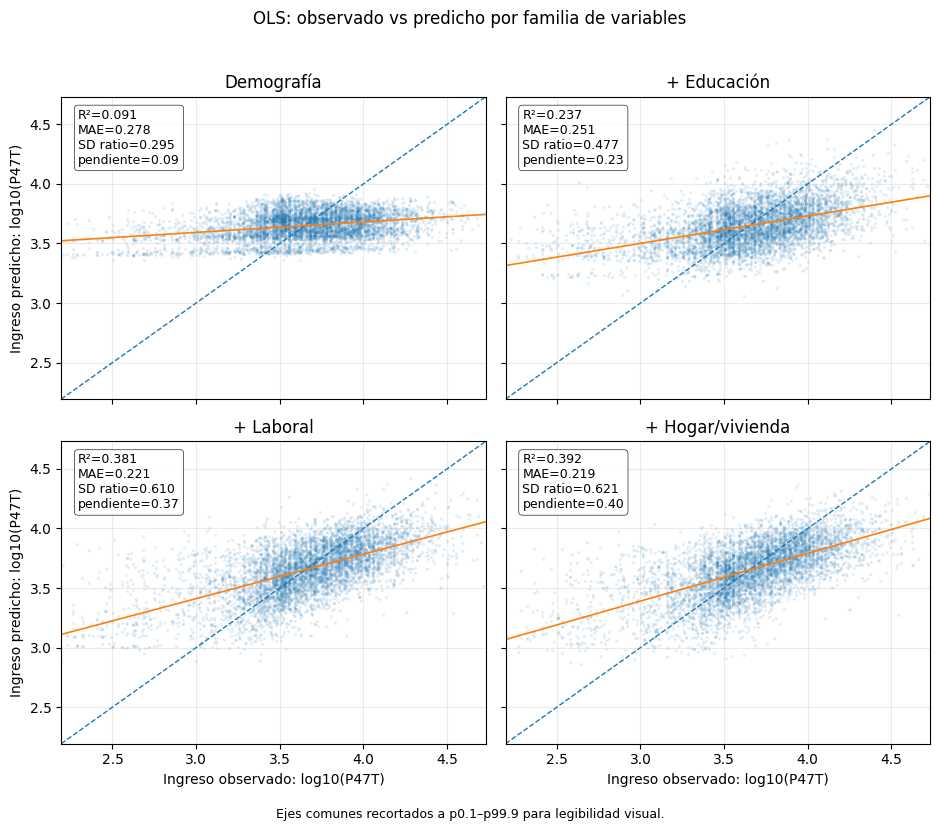

In [8]:
def sample_by_experiment(df: pd.DataFrame, experiments: list[str], split="validation", n_per_experiment=6000, seed=123) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    parts = []
    for exp in experiments:
        g = df.query("split == @split and experiment == @exp").copy()
        if g.empty:
            continue
        n = min(n_per_experiment, len(g))
        idx = rng.choice(g.index.to_numpy(), size=n, replace=False)
        parts.append(g.loc[idx])
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


plot_pred = sample_by_experiment(predictions, MAIN_ORDER, split="validation", n_per_experiment=6000, seed=123)

# Límites robustos para evitar que uno o dos outliers destruyan la lectura visual.
axis_values = pd.concat([plot_pred["y_true"], plot_pred["y_pred"]]).dropna()
lo, hi = axis_values.quantile([0.001, 0.999])
pad = 0.03 * (hi - lo)
lims = (lo - pad, hi + pad)

metric_lookup = (
    metrics_by_prediction
    .query("split == 'validation'")
    .set_index("experiment")
)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, exp in zip(axes, MAIN_ORDER):
    tmp = plot_pred.query("experiment == @exp")
    ax.scatter(tmp["y_true"], tmp["y_pred"], s=5, alpha=0.12, linewidths=0)
    ax.plot(lims, lims, linestyle="--", linewidth=1, label="45°")

    # Línea de calibración visual: y_pred = a + b y_true.
    clean = tmp[["y_true", "y_pred"]].dropna()
    if len(clean) > 5:
        b, a = np.polyfit(clean["y_true"], clean["y_pred"], deg=1)
        xs = np.array(lims)
        ax.plot(xs, a + b * xs, linewidth=1.2)
        slope_text = f"pendiente={b:.2f}"
    else:
        slope_text = "pendiente=NA"

    m = metric_lookup.loc[exp]
    annotation = (
        f"R²={m['r2']:.3f}\n"
        f"MAE={m['mae']:.3f}\n"
        f"SD ratio={m['compression_ratio']:.3f}\n"
        f"{slope_text}"
    )
    ax.text(0.04, 0.96, annotation, transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "linewidth": 0.5})

    ax.set_title(DISPLAY_LABELS[exp])
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel("Ingreso observado: log10(P47T)")
for ax in axes[::2]:
    ax.set_ylabel("Ingreso predicho: log10(P47T)")

fig.suptitle("OLS: observado vs predicho por familia de variables", y=1.02)
fig.text(0.5, 0.01, "Ejes comunes recortados a p0.1–p99.9 para legibilidad visual.", ha="center", fontsize=9)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIG_DIR / "F1_v2_observed_vs_predicted_by_feature_family.png", dpi=180, bbox_inches="tight")
plt.show()


## 08. Errores por decil de ingreso observado

Esta sección traduce la compresión a una lectura por posición en la distribución.

Convención:

```text
residual = y_true - y_pred
```

Entonces:

- residual negativo: el modelo sobrepredice;
- residual positivo: el modelo subpredice.


In [9]:
def assign_deciles_within_split(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["income_decile"] = (
        result.groupby("split")["y_true"]
        .transform(lambda s: pd.qcut(s, 10, labels=False, duplicates="drop") + 1)
    )
    return result


pred_dec = assign_deciles_within_split(predictions)

decile_errors = (
    pred_dec
    .groupby(["experiment", "split", "income_decile"], as_index=False)
    .agg(
        n=("y_true", "size"),
        mean_y_true=("y_true", "mean"),
        mean_y_pred=("y_pred", "mean"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        mae=("abs_error", "mean"),
        rmse=("squared_error", lambda s: np.sqrt(np.mean(s))),
    )
)

decile_errors["experiment_order"] = decile_errors["experiment"].map(ORDER_INDEX)
decile_errors["main_order"] = decile_errors["experiment"].map(MAIN_ORDER_INDEX)
decile_errors["label"] = decile_errors["experiment"].map(DISPLAY_LABELS)
decile_errors.to_csv(TABLE_DIR / "T5_v2_decile_errors.csv", index=False)

validation_deciles = decile_errors.query("split == 'validation' and experiment in @MAIN_ORDER").copy()
validation_deciles.head()


,experiment,split,income_decile,n,mean_y_true,mean_y_pred,mean_residual,median_residual,mae,rmse,experiment_order,main_order,label
30,ols_core_no_pyramid,validation,1,2005,2.884475,3.393675,-0.509200,-0.490253,0.514074,0.594737,3,3.0,+ Hogar/vivienda
31,ols_core_no_pyramid,validation,2,2023,3.319479,3.474252,-0.154773,-0.157720,0.216792,0.264127,3,3.0,+ Hogar/vivienda
32,ols_core_no_pyramid,validation,3,1974,3.454575,3.542964,-0.088389,-0.090353,0.169080,0.210418,3,3.0,+ Hogar/vivienda
33,ols_core_no_pyramid,validation,4,1998,3.534620,3.582515,-0.047895,-0.051898,0.139831,0.178023,3,3.0,+ Hogar/vivienda
34,ols_core_no_pyramid,validation,5,2000,3.619369,3.628597,-0.009228,-0.017013,0.138710,0.175185,3,3.0,+ Hogar/vivienda


## 09. Figura 2 — residual firmado por decil

Esta figura es más informativa que el MAE por decil para la pregunta de compresión. El MAE dice cuánto error hay; el residual firmado dice hacia dónde empuja el modelo.


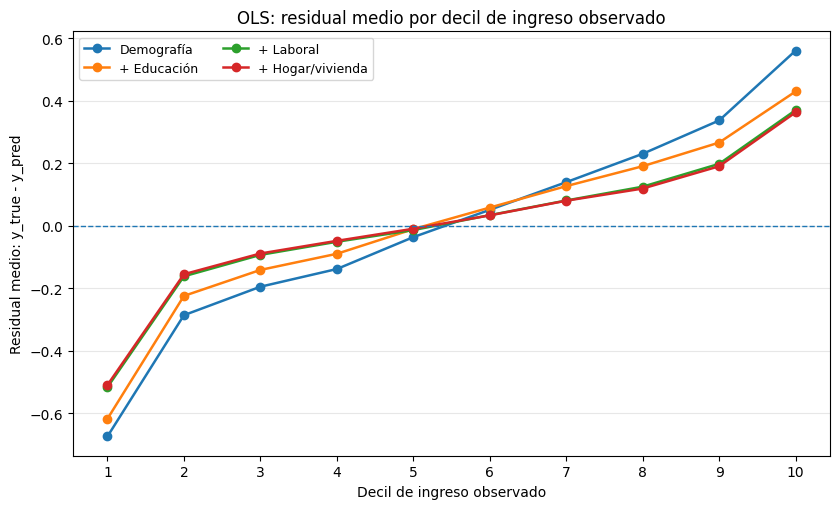

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))

for exp in MAIN_ORDER:
    tmp = validation_deciles.query("experiment == @exp").sort_values("income_decile")
    if tmp.empty:
        continue
    ax.plot(tmp["income_decile"], tmp["mean_residual"], marker="o", linewidth=1.8, label=DISPLAY_LABELS[exp])

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("OLS: residual medio por decil de ingreso observado")
ax.set_xlabel("Decil de ingreso observado")
ax.set_ylabel("Residual medio: y_true - y_pred")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "F2_v2_signed_residual_by_income_decile.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Figura 3 — strip plot de errores absolutos

Esta figura reemplaza el line plot agregado de MAE/RMSE.

El punto no es mostrar cinco promedios, sino ver la dispersión de errores individuales detrás de esos promedios. Para que la figura sea legible se usa una muestra reproducible por especificación y se recorta el eje Y al p99 de `abs_error` en validation. El recorte es visual; las métricas de la tabla usan todos los datos.


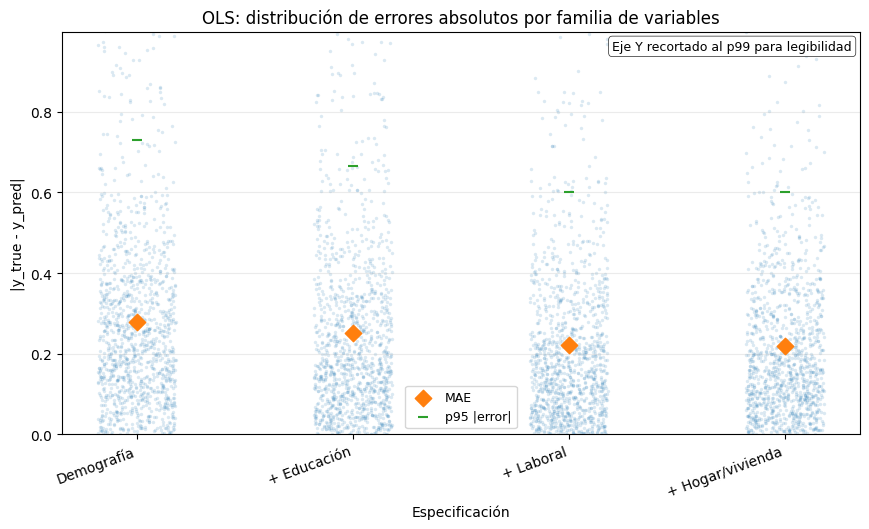

In [11]:
def make_abs_error_strip_sample(df: pd.DataFrame, experiments: list[str], split="validation", n_per_experiment=1000, seed=456) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    parts = []
    for exp in experiments:
        g = df.query("split == @split and experiment == @exp").copy()
        if g.empty:
            continue
        n = min(n_per_experiment, len(g))
        idx = rng.choice(g.index.to_numpy(), size=n, replace=False)
        parts.append(g.loc[idx])
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


strip_df = make_abs_error_strip_sample(predictions, MAIN_ORDER, split="validation", n_per_experiment=1200, seed=456)
strip_df["x_pos"] = strip_df["experiment"].map(MAIN_ORDER_INDEX).astype(float)

rng = np.random.default_rng(789)
strip_df["x_jitter"] = strip_df["x_pos"] + rng.uniform(-0.18, 0.18, size=len(strip_df))

y_cap = predictions.query("split == 'validation' and experiment in @MAIN_ORDER")["abs_error"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8.8, 5.4))
ax.scatter(strip_df["x_jitter"], strip_df["abs_error"], s=6, alpha=0.16, linewidths=0)

# Overlay de MAE usando todos los datos, no solo la muestra.
main_metrics = (
    metrics_by_prediction
    .query("split == 'validation' and experiment in @MAIN_ORDER")
    .sort_values("main_order")
)
ax.scatter(main_metrics["main_order"], main_metrics["mae"], s=70, marker="D", label="MAE", zorder=5)

# Overlay de p95 para recordar que la cola existe aunque el eje esté recortado.
ax.scatter(main_metrics["main_order"], main_metrics["p95_abs_error"], s=55, marker="_", label="p95 |error|", zorder=5)

ax.set_title("OLS: distribución de errores absolutos por familia de variables")
ax.set_xlabel("Especificación")
ax.set_ylabel("|y_true - y_pred|")
ax.set_xticks(range(len(MAIN_ORDER)))
ax.set_xticklabels([DISPLAY_LABELS[e] for e in MAIN_ORDER], rotation=20, ha="right")
ax.set_ylim(0, y_cap)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=9)
ax.text(0.99, 0.98, "Eje Y recortado al p99 para legibilidad", transform=ax.transAxes,
        va="top", ha="right", fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "linewidth": 0.5})
fig.tight_layout()
fig.savefig(FIG_DIR / "F3_v2_absolute_residual_strip_by_feature_family.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Resumen diagnóstico automático

Estas notas son un apoyo para lectura, no prosa final. La prosa final debe revisar si las magnitudes son sustantivamente importantes y cómo conectan con los notebooks de tiempo, geografía y residuales.


In [12]:
def fmt(x, digits=4):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

summary = metrics_by_prediction.query("split == 'validation'").set_index("experiment")
notes = []

if {"ols_demo", "ols_demo_educ"}.issubset(summary.index):
    notes.append(
        "Educación: "
        f"ΔR² = {fmt(summary.loc['ols_demo_educ', 'r2'] - summary.loc['ols_demo', 'r2'])}; "
        f"ΔMAE = {fmt(summary.loc['ols_demo_educ', 'mae'] - summary.loc['ols_demo', 'mae'])}."
    )

if {"ols_demo_educ", "ols_demo_educ_labor"}.issubset(summary.index):
    notes.append(
        "Laboral: "
        f"ΔR² = {fmt(summary.loc['ols_demo_educ_labor', 'r2'] - summary.loc['ols_demo_educ', 'r2'])}; "
        f"ΔMAE = {fmt(summary.loc['ols_demo_educ_labor', 'mae'] - summary.loc['ols_demo_educ', 'mae'])}."
    )

if {"ols_demo_educ_labor", "ols_core_no_pyramid"}.issubset(summary.index):
    notes.append(
        "Hogar/vivienda sin pirámide: "
        f"ΔR² = {fmt(summary.loc['ols_core_no_pyramid', 'r2'] - summary.loc['ols_demo_educ_labor', 'r2'])}; "
        f"ΔMAE = {fmt(summary.loc['ols_core_no_pyramid', 'mae'] - summary.loc['ols_demo_educ_labor', 'mae'])}."
    )

if {"ols_core", "ols_core_no_pyramid"}.issubset(summary.index):
    notes.append(
        "Ablation de pirámide: "
        f"core con pirámide - core sin pirámide ΔR² = {fmt(summary.loc['ols_core', 'r2'] - summary.loc['ols_core_no_pyramid', 'r2'])}; "
        f"ΔMAE = {fmt(summary.loc['ols_core', 'mae'] - summary.loc['ols_core_no_pyramid', 'mae'])}."
    )

if "ols_core_no_pyramid" in summary.index:
    notes.append(
        "Benchmark limpio sin pirámide: "
        f"compression ratio = {fmt(summary.loc['ols_core_no_pyramid', 'compression_ratio'])}. "
        "Valores menores a 1 indican compresión de predicciones respecto del ingreso observado."
    )

# Diagnóstico de cola para benchmark limpio.
core_dec = validation_deciles.query("experiment == 'ols_core_no_pyramid'").sort_values("income_decile")
if not core_dec.empty:
    d1 = core_dec.query("income_decile == 1")["mean_residual"].iloc[0]
    d10 = core_dec.query("income_decile == 10")["mean_residual"].iloc[0]
    notes.append(
        "Errores por cola en benchmark limpio: "
        f"residual medio D1 = {fmt(d1)}; residual medio D10 = {fmt(d10)}. "
        "Con residual = y_true - y_pred, esto indica sobrepredicción abajo y subpredicción arriba."
    )

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)
(TABLE_DIR / "T6_v2_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- Educación: ΔR² = 0.1459; ΔMAE = -0.0274.
- Laboral: ΔR² = 0.1443; ΔMAE = -0.0297.
- Hogar/vivienda sin pirámide: ΔR² = 0.0107; ΔMAE = -0.0024.
- Ablation de pirámide: core con pirámide - core sin pirámide ΔR² = 0.0103; ΔMAE = -0.0022.
- Benchmark limpio sin pirámide: compression ratio = 0.6212. Valores menores a 1 indican compresión de predicciones respecto del ingreso observado.
- Errores por cola en benchmark limpio: residual medio D1 = -0.5092; residual medio D10 = 0.3632. Con residual = y_true - y_pred, esto indica sobrepredicción abajo y subpredicción arriba.


572

## 12. Interpretación provisional

La progresión de familias de variables sugiere que la mayor parte de la señal lineal entra por educación y variables laborales. La demografía sola explica poco. Hogar/vivienda agrega una mejora menor, útil como refinamiento pero no como fuente principal de capacidad predictiva.

La pirámide del hogar se mantiene como ablation: puede mejorar algo el ajuste, pero no cambia la historia central y ensucia el benchmark si se la incorpora por defecto.

La mejora promedio tampoco elimina la falla distribucional. Los paneles observado-vs-predicho y el residual firmado por decil muestran que el OLS sigue comprimiendo la distribución: sobrepredice la parte baja y subpredice la parte alta. Por lo tanto, en este dataset OLS funciona razonablemente como máquina de ordenamiento parcial, pero no reproduce toda la dispersión del ingreso observado.

Esta conclusión prepara los notebooks siguientes: tiempo y geografía preguntan si hay estructura residual específica por calendario o territorio; el notebook de residuales/distribución estudia en detalle la compresión; HGB pregunta si parte de este techo viene de la forma funcional lineal-aditiva.


## 13. Outputs escritos

Tablas:

```text
reports/notebook_outputs/ols_feature_blocks_v2/tables/
  T0_v2_metrics_by_split.csv
  T1_v2_feature_family_progression.csv
  T2_v2_pyramid_ablation.csv
  T3_v2_split_stability.csv
  T4_v2_split_stability_summary.csv
  T5_v2_decile_errors.csv
  T6_v2_diagnostic_notes.txt
```

Figuras:

```text
reports/notebook_outputs/ols_feature_blocks_v2/figures/
  F1_v2_observed_vs_predicted_by_feature_family.png
  F2_v2_signed_residual_by_income_decile.png
  F3_v2_absolute_residual_strip_by_feature_family.png
```

Criterio de aceptación:

- no hay figuras de cuatro números;
- las métricas agregadas están en tablas;
- las figuras muestran fenómenos visuales reales;
- `pyramid` queda separado como ablation;
- el benchmark principal queda limpio;
- la compresión queda demostrada visualmente y cuantificada.
